# Bilibili Video Data - Exploratory Data Analysis

---

## 1. Project Overview

This report explores the performance of 6 videos published on a personal Bilibili channel. The data covers the first 10 days after publication for each video, exported from the Bilibili Creator Dashboard on 23 March 2026.

---

## 2. Data Overview

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
info = pd.read_csv("https://raw.githubusercontent.com/TheClockwise/Data-Analysis-of-Videos-by-a-Bilibili-Content-Creator/main/data/Video_information.csv")
perf = pd.read_csv("https://raw.githubusercontent.com/TheClockwise/Data-Analysis-of-Videos-by-a-Bilibili-Content-Creator/main/data/Video_performance_over_time.csv")

In [4]:
print("The first few rows of video performance:\n", perf.head())
print("Data size of video performance:\n", perf.shape)
print("Data types of video performance:\n", perf.dtypes)
print("Missing values in video performance:\n", perf.isnull().sum())

The first few rows of video performance:
       bv_number        date  days_since_publish  views  new_followers  \
0  BV1GT4PzEEhd  12/10/2025                   0    418              0   
1  BV1GT4PzEEhd  13/10/2025                   1      5              0   
2  BV1GT4PzEEhd  14/10/2025                   2      2              0   
3  BV1GT4PzEEhd  15/10/2025                   3      2              0   
4  BV1GT4PzEEhd  16/10/2025                   4      1              0   

   unfollows  likes  danmaku  comments  shares  favorites  coins  
0          0      8        0         1       0          0      0  
1          0      0        0         0       0          0      0  
2          0      0        0         0       0          0      0  
3          0      0        0         0       0          0      0  
4          0      0        0         0       0          0      0  
Data size of video performance:
 (60, 12)
Data types of video performance:
 bv_number             object
date        

In [5]:
print("The first few rows of video information:\n", info.head())
print("Data size of video information:\n", info.shape)
print("Data types of video information:\n", info.dtypes)
print("Missing values in video information:\n", info.isnull().sum())

The first few rows of video information:
       bv_number video_title_short  \
0  BV1GT4PzEEhd            4words   
1  BV15skLB6ED7             widow   
2  BV1VEz1BLEum            kuromu   
3  BV12GP2zvEXW             furen   
4  BV1KfPjzQE1V             laser   

                                      video_title_en  \
0  You know what I'm going to say. I won't leave ...   
1  Testing the Widowmaker cheat: If it can't even...   
2  [No translation needed] Cute Kuromu is shaking...   
3  [Translated] Furen talks about singing bass in...   
4                          Do you like my big laser?   

             video_title_tc            video_title_sc publish_date  \
0   你知道我要說什麼 沒聽到那四個字前我是不會走的   你知道我要说什么 没听到那四个字前我是不会走的   12/10/2025   
1        鑒掛黑百合 路都不會走怎麼可能打得中        鉴挂黑百合 路都不会走怎么可能打得中    20/1/2026   
2  【不用熟】可愛kuromu在兩個解說中間搖頭晃腦  【不用熟】可爱kuromu在两个解说中间摇头晃脑    24/1/2026   
3       【熟肉】芙蓮聊到她在ray唱低音的事情       【熟肉】芙莲聊到她在ray唱低音的事情     6/3/2026   
4                 喜不喜歡我的大激光                 喜不喜欢

---

## 3. Data Cleaning and Preparation

We change the data type of `date` and `publish_date` from `object` to `datetime64` in both csv file. `bounc_rate` and `avg_playbacl_progess` are stored as strings with a `%` sign. We strip the symbol and convert them to `float`. We sum up the `views` by `bv_number` in video performance and merge them with `video_title_short` and `category` from video information. Then, we attach the same columns to the video performance for easier analysis later.

In [6]:
perf["date"] = pd.to_datetime(perf["date"], format="%d/%m/%Y")
info["publish_date"] = pd.to_datetime(info["publish_date"], format="%d/%m/%Y")

info["bounce_rate"] = info["bounce_rate"].str.replace("%","").astype(float)
info["avg_playback_progress"] = info["avg_playback_progress"].str.replace("%","").astype(float)

total_views = perf.groupby("bv_number")["views"].sum().reset_index(name="total_views").merge(info[["bv_number", "video_title_short", "category"]], on="bv_number").sort_values(by="total_views", ascending=False)

perf_labeled = perf.merge(info[["bv_number", "video_title_short", "category"]], on="bv_number")

---

## 4. Exploratory Data Analysis

### 4.1 Univariate Analysis

We examine each variable on its own. The goal is to understand the basic shape, center and spread of the data before comparing variables.

### Summary Statistics of Video Performance

We use `describe()` to get the count, mean, standard deviation, minimum and maximum for every numeric column in the daily performance table.

In [7]:
perf.describe().round(2)

,date,days_since_publish,views,new_followers,unfollows,likes,danmaku,comments,shares,favorites,coins
count,60,60.0,60.00,60.00,60.0,60.00,60.00,60.00,60.00,60.00,60.00
mean,2026-02-01 08:00:00,4.5,109.27,0.08,0.0,2.35,0.07,0.42,0.05,0.88,0.15
min,2025-10-12 00:00:00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,2026-01-24 00:00:00,2.0,5.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
50%,2026-02-18 00:00:00,4.5,14.50,0.00,0.0,1.00,0.00,0.00,0.00,0.00,0.00
75%,2026-03-13 00:00:00,7.0,191.00,0.00,0.0,2.00,0.00,0.00,0.00,0.00,0.00
max,2026-03-21 00:00:00,9.0,860.00,1.00,0.0,27.00,2.00,6.00,2.00,20.00,2.00
std,NaN,2.9,186.51,0.28,0.0,4.89,0.31,1.11,0.29,3.56,0.52


There are 60 rows in total (6 videos * 10 days). Most engagement columns (`danmaku`, `comments`,	`shares`,	`coins`) have a mean close to zero and a small maximum, telling us that most days and most videos received almost no interaction. `views` show high variability. The standard deviation of `views` (186.51) is larger than the mean(109.27), indicating a right-skewed distribution with occasional outliers.

### Distribution of Daily Views

A histogram can show the shape of the daily view counts acroos all 60 observations. We can draw a vertical line at the median to mark the centre of the distribution.

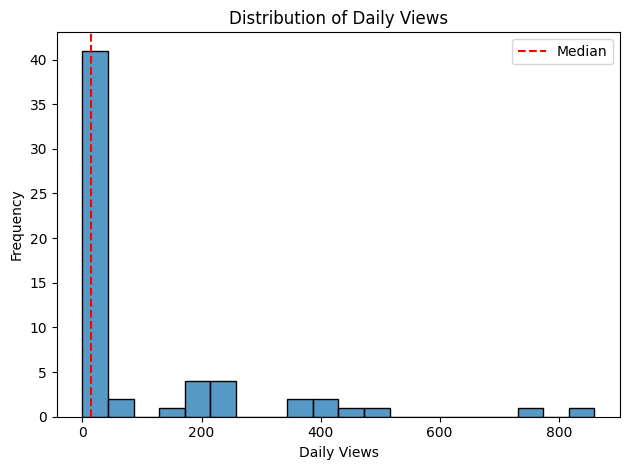

In [8]:
median_views = np.median(perf["views"])

ax = sns.histplot(perf["views"], bins=20)
ax.axvline(median_views, color="red", linestyle="--", label="Median")
ax.set(
    title="Distribution of Daily Views",
    xlabel="Daily Views",
    ylabel="Frequency"
)
ax.legend()
plt.tight_layout()
plt.show()

The histogram confirms a strong right skew. Most daily view counts are below 100 with a median of just 14.5 views. However, a few days with several hundred views push the mean far above the median.

### Boxplot of Daily Views per Video

A boxplot shows the first quartile, median, third quartile and outliers for each video respectively. We also give the inter-quartile range (IQR) and outliers for each video to make the graph more detailed.

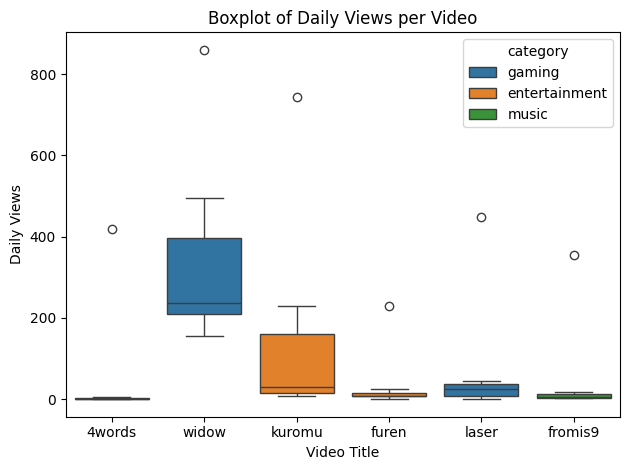

In [9]:
ax = sns.boxplot(
    data=perf_labeled,
    x="video_title_short",
    y="views",
    hue="category"
)
ax.set(
    title = "Boxplot of Daily Views per Video",
    xlabel = "Video Title",
    ylabel = "Daily Views"
)
plt.tight_layout()
plt.show()

In [10]:
for title, grp in perf_labeled.groupby("video_title_short")["views"]:
  q1, q3 = grp.quantile([0.25, 0.75])
  iqr = q3 - q1
  lt = q1 - 1.5 * iqr
  ut = q3 + 1.5 * iqr
  outliers = grp[(grp < lt) | (grp > ut)].tolist()
  print("IQR =", iqr)
  print("Outliers =", outliers)

IQR = 2.0
Outliers = [418]
IQR = 7.75
Outliers = [356]
IQR = 9.25
Outliers = [229]
IQR = 145.0
Outliers = [745]
IQR = 30.75
Outliers = [448]
IQR = 187.25
Outliers = [860]


`widow` has by far the widest box and the highest outlier values. `4words` has IQR = 2, telling us the middle 50% of daily observations fall within a narrow range of just 2 views. The other three videos (except `kuromu`) show a similar shape that a box compressed near zero with one outlier point.

### Summary Statistics of Video Information

We use `describe()` to get the count, mean, standard deviation, minimum and maximum for every numeric column in the video metadata table.

In [11]:
info.describe().round(2)

,publish_date,duration_sec,cover_click_score,bounce_rate,avg_playback_progress
count,6,6.00,6.00,6.00,6.00
mean,2026-01-27 20:00:00,99.83,3.90,29.68,41.93
min,2025-10-12 00:00:00,27.00,3.00,18.90,30.70
25%,2026-01-21 00:00:00,61.25,3.25,20.52,32.88
50%,2026-02-13 12:00:00,88.50,3.85,30.35,40.45
75%,2026-03-07 12:00:00,112.00,4.53,36.80,51.18
max,2026-03-12 00:00:00,223.00,4.90,42.30,54.90
std,NaN,68.27,0.79,10.12,10.81


* Video duration range from 27 to 223 seconds, with mean of about 100 second.
* Cover click scores range from 3.0 to 4.9, with mean of 3.9.
* Bounce rates range from 18.9% to 42.3%. It means that roughly between 1 in 5 and 1 in 2 viewers leave within the first three seconds.
* Average playback progress ranges from 30.7% to 54.9%. It shows that viewers typically watch less than hald of each video on average.

---

### 4.2 Bivariate Analysis
We now look at pairs of variables to find associations.

### Total Views by Category


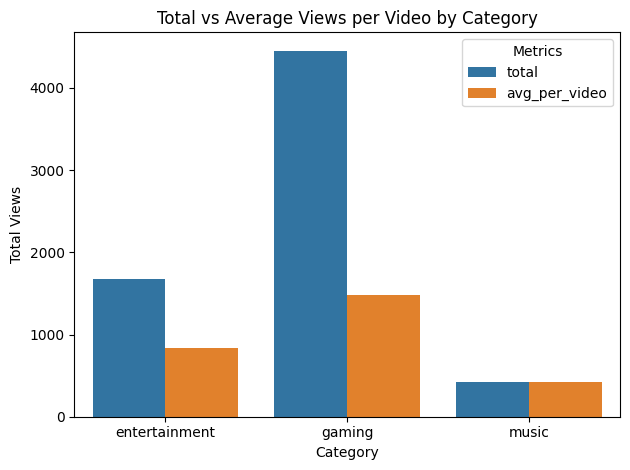

In [12]:
views_by_cate = total_views.groupby("category")["total_views"].agg(["sum", "mean"]).rename(columns={"sum": "total", "mean": "avg_per_video"}).reset_index()

views_by_cate = views_by_cate.melt(
    id_vars="category",
    value_vars=["total", "avg_per_video"],
    var_name="metric",
    value_name="value"
)

ax = sns.barplot(data=views_by_cate, x="category", y="value", hue="metric")
ax.set(
    title="Total vs Average Views per Video by Category",
    xlabel="Category",
    ylabel="Total Views"
)
ax.legend(title="Metrics")
plt.tight_layout()
plt.show()

Gaming has the highest total and average views. However, this is largely driven by `widow`. Entertainment and music have comparable per-viddeo averages when `widow` is excluded. The fact that gaming has 3 videos while entertainment has 2  and music has 1 makes a direct category comparison unreliable at this sample size.

### Cover Click Score vs Total Views

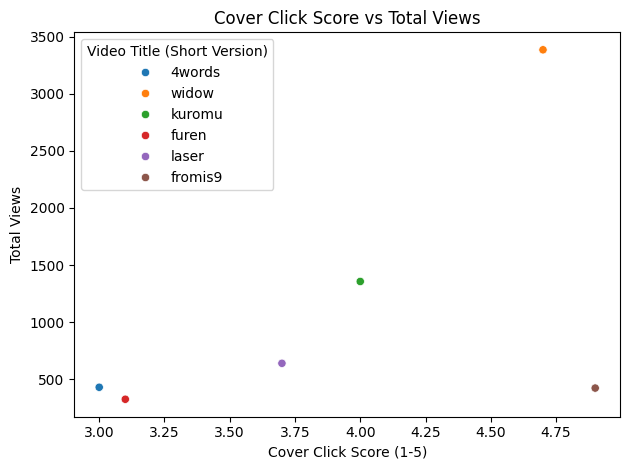

In [13]:
combined = info.merge(total_views[["bv_number", "total_views"]], on="bv_number")

ax = sns.scatterplot(data=combined, x="cover_click_score", y="total_views", hue="video_title_short")
ax.set(
    title="Cover Click Score vs Total Views",
    xlabel="Cover Click Score (1-5)",
    ylabel="Total Views"
)
ax.legend(title="Video Title (Short Version)")
plt.tight_layout()
plt.show()

There is no clear positive trend between cover click score and total views. `widow` has the most total views despite a cover click score of 4.7. In contrast, `fromis9` has the highest score of 4.9 but earned fewer views. `4words` scored lowest (3.0) and had the fewest views. Although this is directionally consistent, one data point cannot confirm the pattern.

### Daily Views Over Time by Video

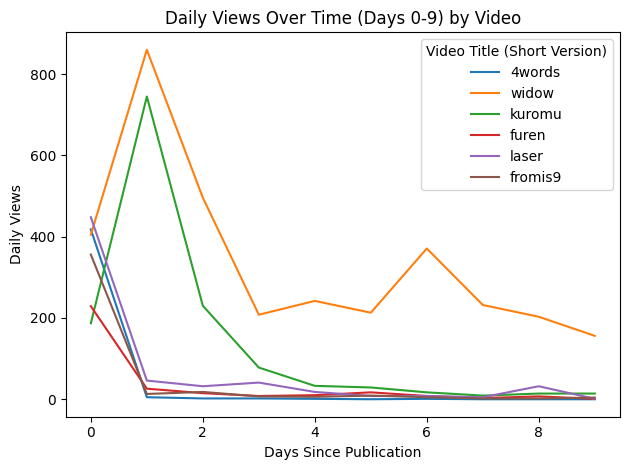

In [14]:
ax = sns.lineplot(data=perf_labeled, x="days_since_publish", y="views", hue="video_title_short")
ax.set(
    title="Daily Views Over Time (Days 0-9) by Video",
    xlabel="Days Since Publication",
    ylabel="Daily Views"
)
ax.legend(title="Video Title (Short Version)")
plt.tight_layout()
plt.show()

Most videos peak on day 0 (the day of publication) and decay quickly to nearly zero by day 3 or 4. There are two clear exceptions. `widow` peaked on day 1 with 860 views compared to 405 on day 0. `Kuromu` also peaked on day 1 with 745 views compared to 187 on day 0. After the peak, all videos converge into a long, flat tail of very low daily views.

---

### 4.3 Multivariate Analysis

We now look at three or more variables at the same time.

### Engagement Metrics Heatmap

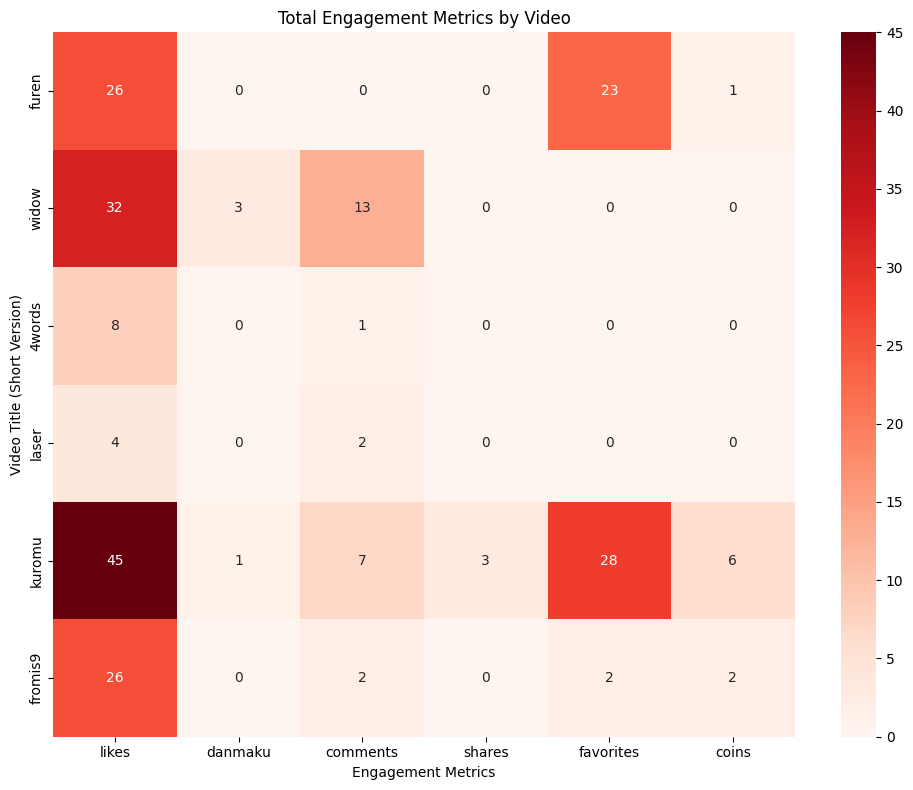

In [15]:
enga_cols = ["likes", "danmaku", "comments", "shares", "favorites", "coins"]

enga_total = perf.groupby("bv_number")[enga_cols].sum().reset_index().merge(info[["bv_number", "video_title_short"]], on="bv_number").set_index("video_title_short").drop(columns="bv_number")

plt.figure(figsize=(10, 8))
ax = sns.heatmap(enga_total, annot=True, cmap="Reds")
ax.set(
    title="Total Engagement Metrics by Video",
    xlabel="Engagement Metrics",
    ylabel="Video Title (Short Version)"
)
plt.tight_layout()
plt.show()

Despite not having the most views, `kuromu` has the highest number of likes (45) and favorites (28). It indicates that it generates a deeper response per viewer. `widow` has the most comments (13). The gaming videos `4words` and `laser` are nearly empty across all engagement metrics except basic views. Overall, the engagement numbers are small everywhere.

---

## 5. Final Report and Presentation

### 5.1 Key Findings
**View Patterns**
- All 6 videos follow a surge-then-decline pattern, with nearly all views earned within the first 3 days after publication. Since then, daily views drop to almost zero and stay flat for the rest of the time.
- `widow` and `kuromu` are notable exceptions. They both peaked on day 1 rather than day 0, suggesting that maybe the Bilibili recommendation algorithm gave them wider exposure the day after upload.

**Engagement**
- `kuromu` generated the highest likes (45) and favorites (28) despite not having the most total views. It indicate that entertainment content tends to produce a stronger emotional response per viewer on this channel.
- The two gaming videos `4words` and `laser` had near-zero engagement across all metrics beyond basic views, suggesting that the audience connects less deeply with gaming content.

**Thumbnail**
- Cover click score does not clearly predict total views in this dataset. While `fromis9` has the highest cover click score (4.9), they have modest total views. In contrast, `widow` ranks second in cover score, but leads in total views by a wide margin.


### 5.2 Limitations of the Analysis

- **Very small sample size**: With only 6 videos, it is difficult to obtain reliable statistical results and derive meaningful business insights from this.
- **Non-independent of daily observations**: The 60 observations in video performance are not independent because each day's views of a video are influenced by the previous days.
- **Different publication dates and topics**: Videos were published across different months and each covers a different game or artist. Platform algorithm changes, seasonal trends or the popularity of a specific topic may explain performance differences better than any content-level factor we can measure here.